In [19]:
import math

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme()

In [20]:
def freq_plot():
    plt.xscale("log")
    plt.xticks(
        [60, 100, 230, 500, 1100, 2400, 5400, 12000],
        ["60", "100", "230", "500", "1.1k", "2.4k", "5.4k", "12k"],
    )

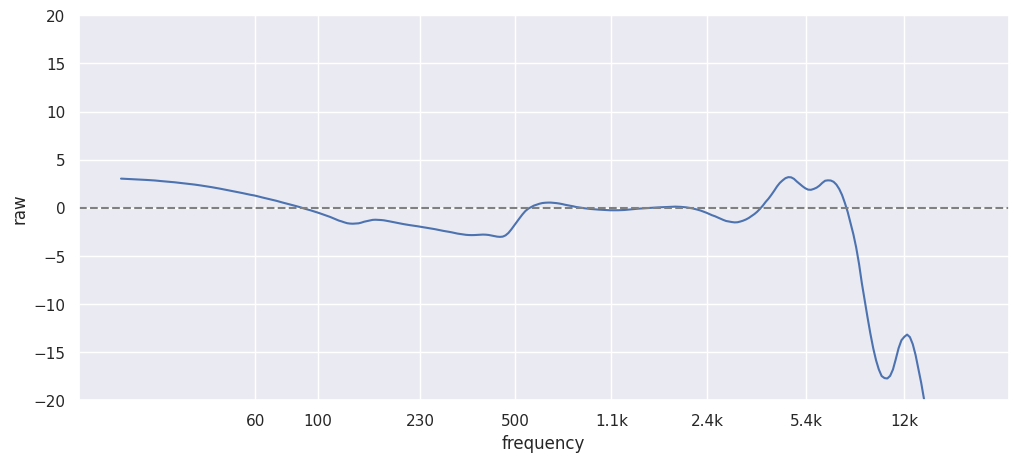

In [21]:
df = pd.read_json("../measurements/soundguys/data.json").rename(columns={"x": "frequency", "y": "raw"})

# "Delinearize" according to delinearization_script.js
df["frequency"] = math.e ** (df["frequency"])
df["raw"] = (df["raw"] - 5) / 1

plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x="frequency", y="raw")
df.to_csv("../measurements/SoundGuys (main eq, ANC Off).csv", index=False)

plt.xscale("log")
plt.axhline(0, color="grey", linestyle="--")
plt.ylim(-20, 20)
freq_plot()
plt.show()